In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve

# ---------- Data Processing ----------

In [2]:
df = pd.read_csv('loan_data.csv')
df

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


# Add Feature

In [3]:
df['annual_inc'] = np.exp(df['log.annual.inc'])
df['risk_score'] = (

      (df['inq.last.6mths'] >= 3).astype(int)

    + (df['revol.util']     >= 70).astype(int)

    + (df['pub.rec']         >  0).astype(int)

    + (df['fico']           < 690).astype(int)

    + (((df['installment'] * 12) / (df['annual_inc'] + 1)) >= 0.10).astype(int)

    + (df['purpose'] == 'small_business').astype(int)

)
df['installment_to_inc'] = (df['installment'] * 12) / (df['annual_inc'] + 1)
df['revol_stress'] = df['revol.bal'] * (df['revol.util'] / 100)
df['fico_int_rate_ratio'] = df['fico'] / (df['int.rate'] * 100)   # เก็บตัวนี้ ตัด credit_risk_ratio
df['policy_inquiry_risk'] = (1 - df['credit.policy']) * 3 + df['inq.last.6mths'].clip(upper=6)
df['util_fico_mismatch'] = df['revol.util'] / (df['fico'] + 1e-6)
df['policy_fico_mismatch'] = (
    (df['credit.policy'] == 0) & (df['fico'] > df['fico'].median())
).astype(int)

df['revol_bal_to_inc'] = df['revol.bal'] / (df['annual_inc'] + 1)

df['inq_per_credit_age'] = df['inq.last.6mths'] / ((df['days.with.cr.line'] / 365) + 1)

# Analyse using the loan utilization vs purpose by classifying it based on loan repayment

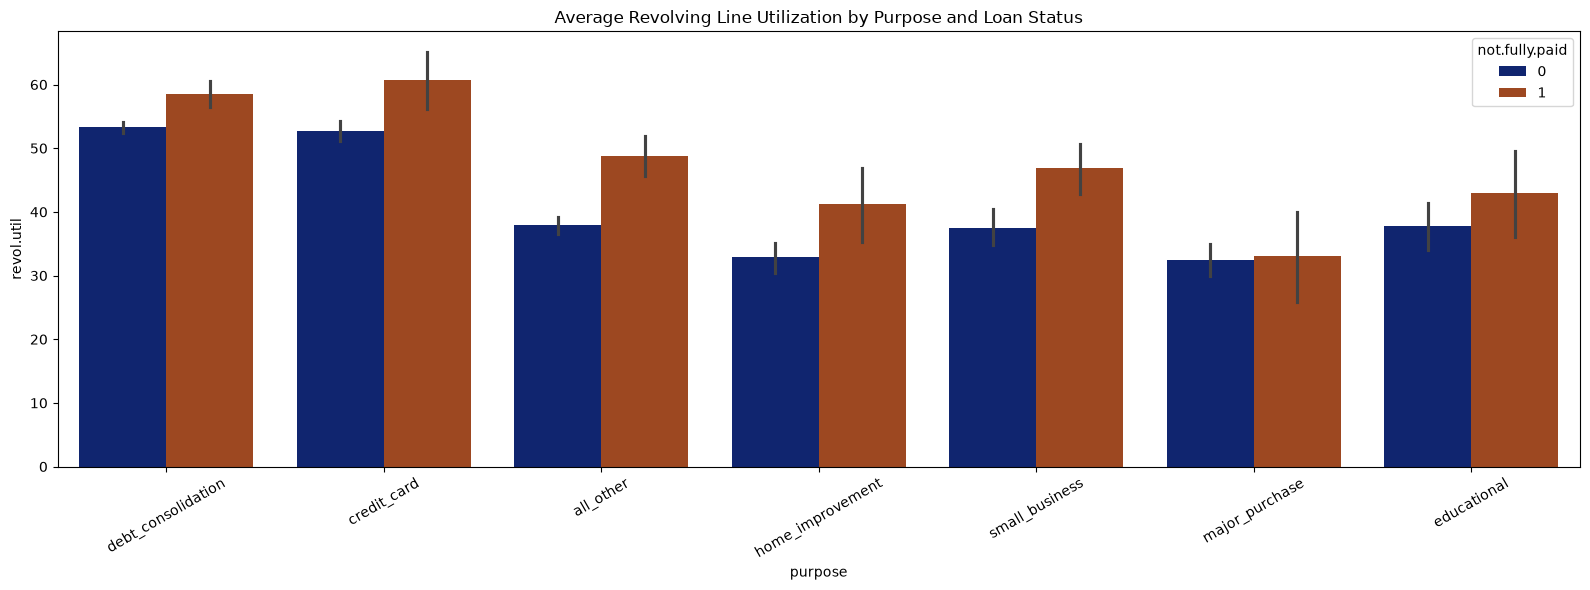

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.barplot(data=df,x='purpose',y='revol.util',hue='not.fully.paid',palette='dark')
plt.xticks(rotation=30)  
plt.title('Average Revolving Line Utilization by Purpose and Loan Status')
plt.tight_layout()       
plt.show()

# Analyse based on the Debt to Income Ratio w.r.t annual income

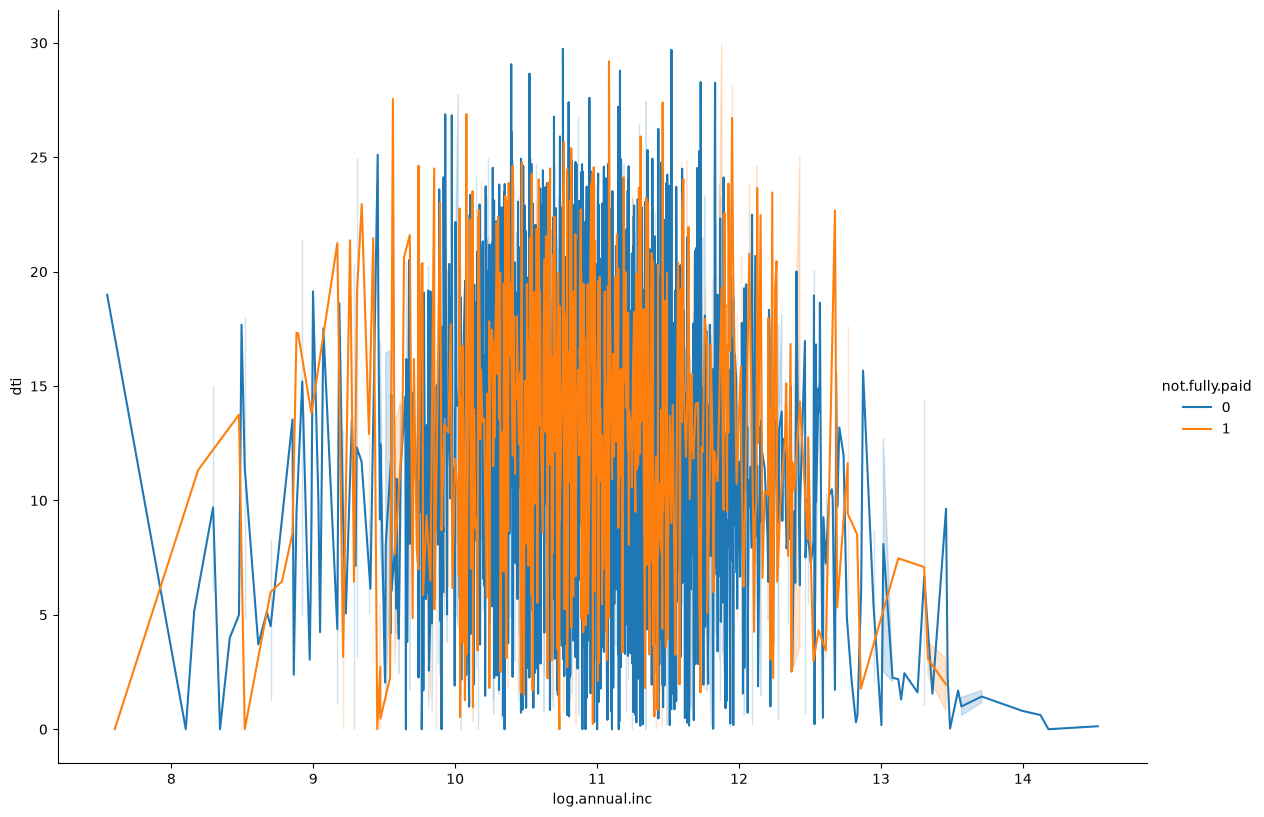

In [5]:
sns.relplot(x='log.annual.inc',y='dti',hue='not.fully.paid',kind='line',data=df,height = 8.27, aspect = 11.7/8.27)

# encode

In [6]:
df_data = pd.get_dummies(df, columns=['purpose'], drop_first=True)

df_data

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,util_fico_mismatch,policy_fico_mismatch,revol_bal_to_inc,inq_per_credit_age,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,...,0.070692,0,0.339455,0.000000,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,...,0.108487,0,0.517269,0.000000,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,...,0.037537,0,0.109715,0.071921,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,...,0.102809,0,0.396078,0.119088,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,...,0.059220,0,0.058663,0.000000,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,...,0.122173,0,1.104466,0.067349,False,False,False,False,False,False
9574,0,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,...,0.001524,1,0.002667,0.384615,False,False,False,False,False,False
9575,0,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,...,0.120670,0,0.250894,0.765391,False,True,False,False,False,False
9576,0,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,...,0.004624,0,0.000000,0.842956,False,False,False,True,False,False


# Correlation


In [7]:
corr = df_data.corr()

print("--- Correlation with Target (not.fully.paid) ---")
print(corr['not.fully.paid'].sort_values(ascending=False))

--- Correlation with Target (not.fully.paid) ---
not.fully.paid                1.000000
risk_score                    0.189478
policy_inquiry_risk           0.175061
int.rate                      0.159552
inq.last.6mths                0.149452
inq_per_credit_age            0.111132
util_fico_mismatch            0.088716
purpose_small_business        0.084460
revol.util                    0.082088
installment_to_inc            0.074137
revol_bal_to_inc              0.056292
revol_stress                  0.055985
revol.bal                     0.053699
installment                   0.049955
pub.rec                       0.048634
policy_fico_mismatch          0.040895
dti                           0.037362
purpose_educational           0.021609
delinq.2yrs                   0.008881
purpose_home_improvement      0.007272
annual_inc                   -0.007425
purpose_debt_consolidation   -0.017543
purpose_major_purchase       -0.028580
days.with.cr.line            -0.029237
log.annual.inc 

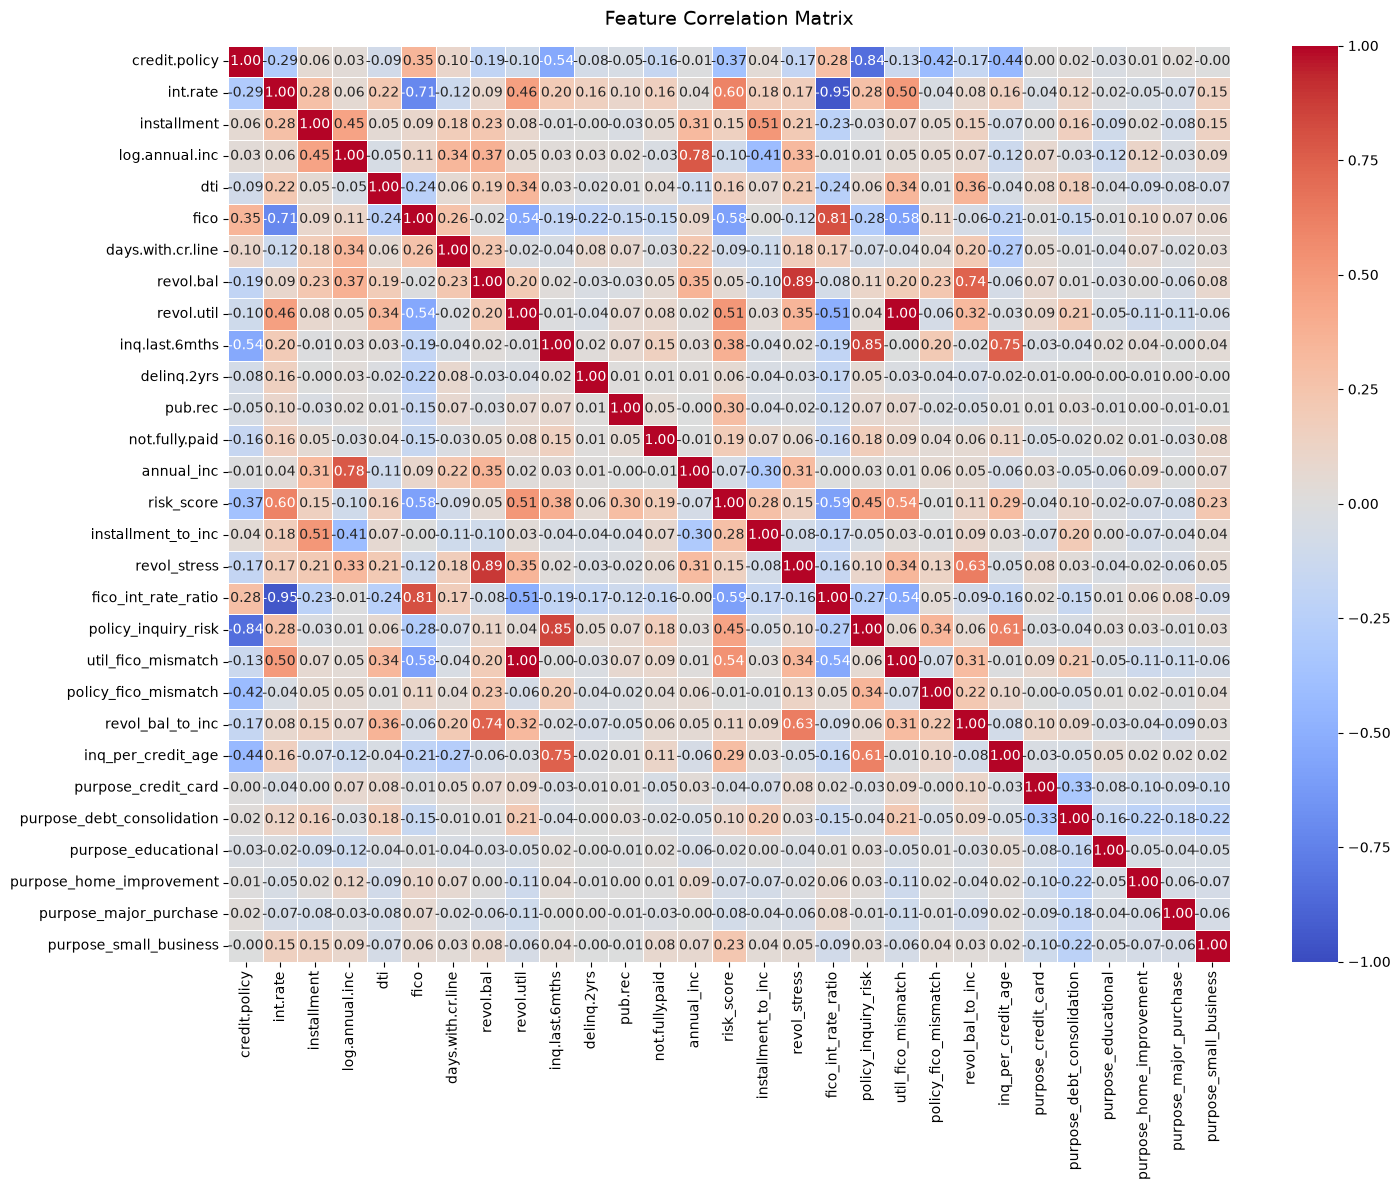

In [8]:
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr,
    annot=True,  
    fmt='.2f',  
    cmap='coolwarm',  
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

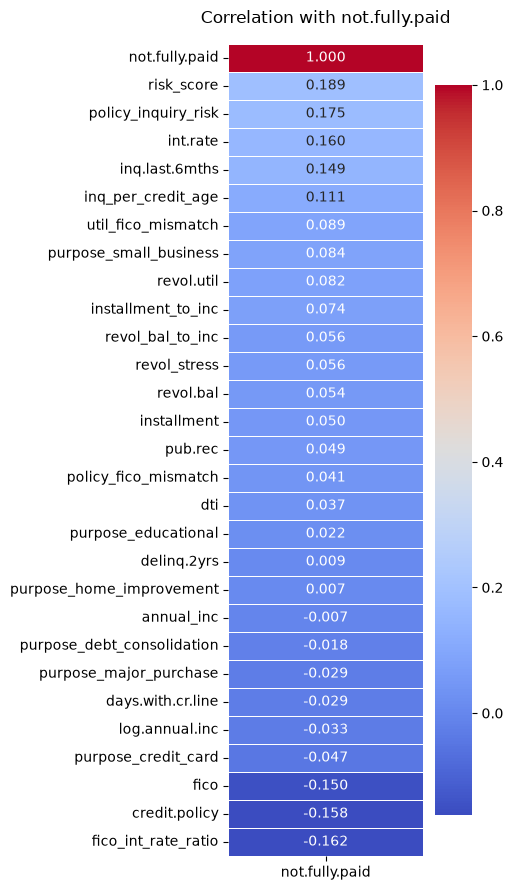

In [9]:
corr = df_data.corr()

target_corr = pd.DataFrame(corr['not.fully.paid'].sort_values(ascending=False))

plt.figure(figsize=(5, 9)) 

sns.heatmap(
    target_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    cbar=True,
    annot_kws={'size': 10}, 
    linewidths=0.5,  
)

plt.title('Correlation with not.fully.paid', fontsize=12, pad=15)
plt.yticks(rotation=0)  
plt.tight_layout()
plt.show()

In [10]:
print(corr, None)

                            credit.policy  int.rate  installment  \
credit.policy                    1.000000 -0.294089     0.058770   
int.rate                        -0.294089  1.000000     0.276140   
installment                      0.058770  0.276140     1.000000   
log.annual.inc                   0.034906  0.056383     0.448102   
dti                             -0.090901  0.220006     0.050202   
fico                             0.348319 -0.714821     0.086039   
days.with.cr.line                0.099026 -0.124022     0.183297   
revol.bal                       -0.187518  0.092527     0.233625   
revol.util                      -0.104095  0.464837     0.081356   
inq.last.6mths                  -0.535511  0.202780    -0.010419   
delinq.2yrs                     -0.076318  0.156079    -0.004368   
pub.rec                         -0.054243  0.098162    -0.032760   
not.fully.paid                  -0.158119  0.159552     0.049955   
annual_inc                      -0.008860  0.039

# XGBClassifier

In [12]:
X = df_data.drop(columns=['not.fully.paid', 'annual_inc'])
y = df_data['not.fully.paid']


# แบ่งเป็น train/test

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
raw_weight = (len(y_train_sub) - sum(y_train_sub)) / sum(y_train_sub)
scale_pos_weight_value = np.sqrt(raw_weight)
print(scale_pos_weight_value)
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    eval_metric='aucpr',
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    early_stopping_rounds=30,
    random_state=42
)

2.2907872930541475


In [15]:

model.fit(X_train_sub, y_train_sub, eval_set=[(X_val, y_val)], verbose=False)
print("Model trained successfully")

Model trained successfully


In [16]:
y_val_probs = model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

In [17]:
print(f"Optimal Threshold (from Validation Set): {best_threshold:.4f}")
print(f'Max F1-Score: {f1_scores[best_idx]:.4f}')

Optimal Threshold (from Validation Set): 0.2958
Max F1-Score: 0.3510


In [18]:
y_test_probs = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)
print("\n=== Classification Report on Test Set ===")
print(classification_report(y_test, y_test_pred))


=== Classification Report on Test Set ===
              precision    recall  f1-score   support

           0       0.89      0.64      0.74      1609
           1       0.24      0.59      0.34       307

    accuracy                           0.63      1916
   macro avg       0.56      0.61      0.54      1916
weighted avg       0.79      0.63      0.68      1916



In [19]:
auc_score = roc_auc_score(y_test, y_test_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.6686


# important

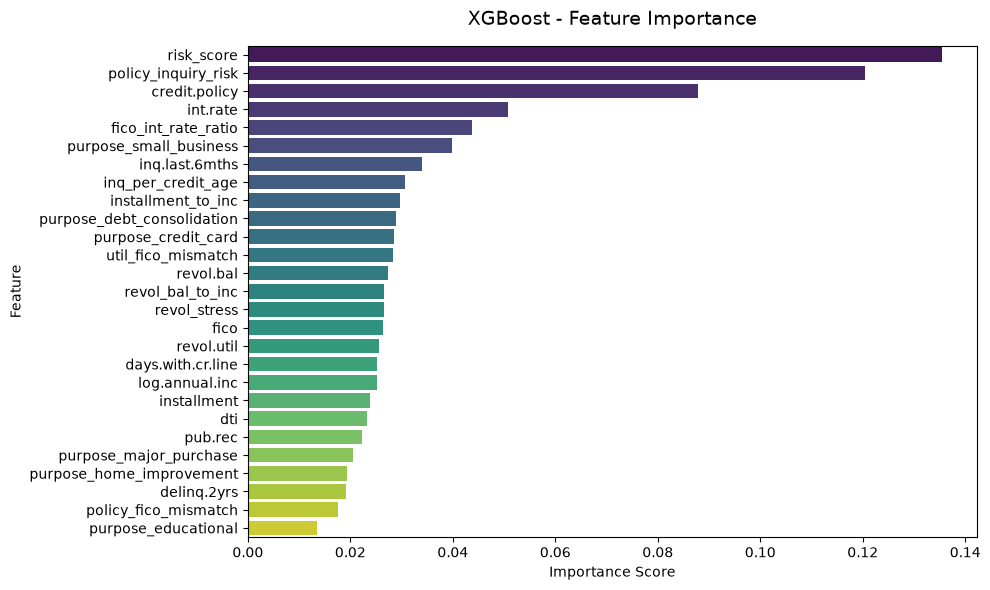

In [20]:
importance_df = pd.DataFrame(
    {'Feature': X_train.columns, 'Importance': model.feature_importances_}
).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis',
    hue='Feature',
    legend=False,
)

plt.title('XGBoost - Feature Importance', fontsize=14, pad=15)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [21]:
print(importance_df)

                       Feature  Importance
12                  risk_score    0.135532
16         policy_inquiry_risk    0.120435
0                credit.policy    0.087777
1                     int.rate    0.050740
15         fico_int_rate_ratio    0.043715
26      purpose_small_business    0.039824
9               inq.last.6mths    0.034056
20          inq_per_credit_age    0.030750
13          installment_to_inc    0.029785
22  purpose_debt_consolidation    0.028824
21         purpose_credit_card    0.028576
17          util_fico_mismatch    0.028253
7                    revol.bal    0.027272
19            revol_bal_to_inc    0.026566
14                revol_stress    0.026491
5                         fico    0.026405
8                   revol.util    0.025540
6            days.with.cr.line    0.025251
3               log.annual.inc    0.025146
2                  installment    0.023824
4                          dti    0.023168
11                     pub.rec    0.022203
25      pur